# Entrenamiento del modelo de estimación de edad\n\nResNet-50 preentrenado en ImageNet, fine-tuned para regresión de edad sobre el dataset `facial-age` de Kaggle.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import models
from PIL import Image
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import albumentations as A
from albumentations.pytorch import ToTensorV2
import random

DATASET_ROOT = "/home/dorfin/dataset/face_age"
OUTPUT_MODEL = "age_model.pth"
BATCH_SIZE   = 32
EPOCHS       = 20
LR           = 1e-4
PATIENCE     = 5     # early stopping

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

/home/dorfin/.local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cuda


## 1. Exploración del dataset

Total imágenes : 9,778
Rango de edades: 1 – 110 años
Menores (<18)  : 3,925 imágenes
Adultos (>=18) : 5,853 imágenes


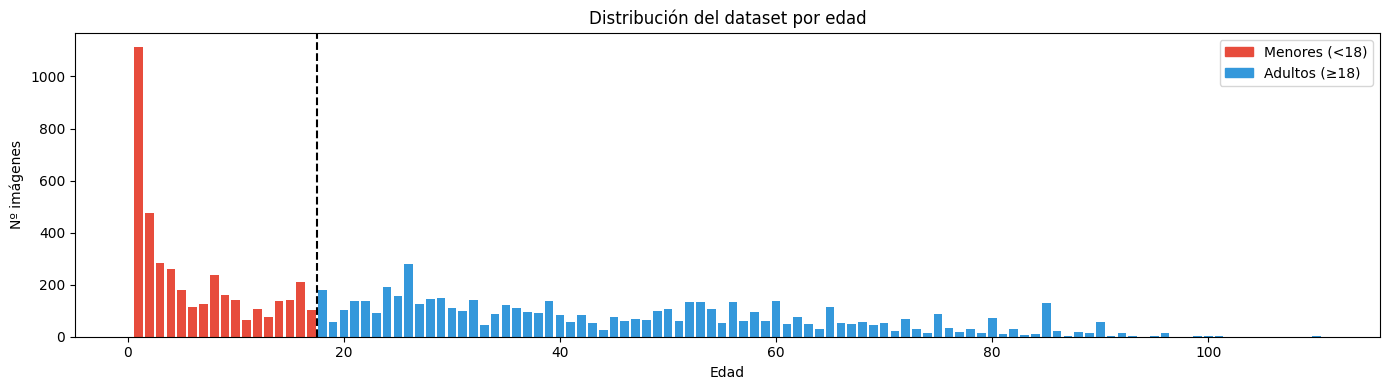

In [3]:
# Distribución de imágenes por edad
ages, counts = [], []
for folder in sorted(Path(DATASET_ROOT).iterdir()):
    if not folder.is_dir():
        continue
    try:
        age = int(folder.name)
    except ValueError:
        continue
    n = len(list(folder.glob("*.png"))) + len(list(folder.glob("*.jpg")))
    ages.append(age)
    counts.append(n)

print(f"Total imágenes : {sum(counts):,}")
print(f"Rango de edades: {min(ages)} – {max(ages)} años")
print(f"Menores (<18)  : {sum(c for a,c in zip(ages,counts) if a < 18):,} imágenes")
print(f"Adultos (>=18) : {sum(c for a,c in zip(ages,counts) if a >= 18):,} imágenes")

plt.figure(figsize=(14, 4))
colors = ["#e74c3c" if a < 18 else "#3498db" for a in ages]
plt.bar(ages, counts, color=colors)
plt.axvline(x=17.5, color="black", linestyle="--", linewidth=1.5, label="Límite menor (18)")
plt.xlabel("Edad")
plt.ylabel("Nº imágenes")
plt.title("Distribución del dataset por edad")
plt.legend(handles=[
    plt.Rectangle((0,0),1,1, color="#e74c3c", label="Menores (<18)"),
    plt.Rectangle((0,0),1,1, color="#3498db", label="Adultos (≥18)"),
], loc="upper right")
plt.tight_layout()
plt.show()

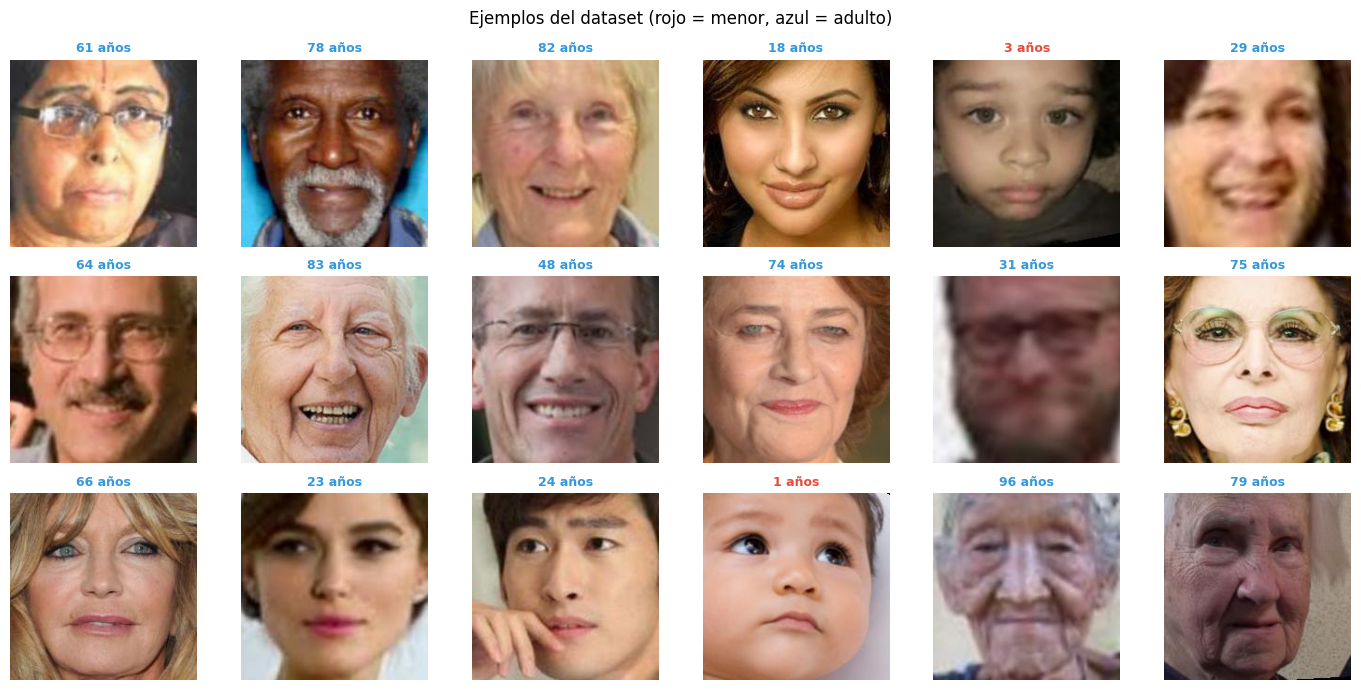

In [4]:
# Muestra ejemplos de imágenes del dataset
fig, axes = plt.subplots(3, 6, figsize=(14, 7))
sample_ages = random.sample(ages, 18)
for ax, age in zip(axes.flat, sample_ages):
    folder = Path(DATASET_ROOT) / f"{age:03d}"
    img_path = random.choice(list(folder.glob("*.png")) + list(folder.glob("*.jpg")))
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    color = "#e74c3c" if age < 18 else "#3498db"
    ax.set_title(f"{age} años", fontsize=9, color=color, fontweight="bold")
    ax.axis("off")
plt.suptitle("Ejemplos del dataset (rojo = menor, azul = adulto)", fontsize=12)
plt.tight_layout()
plt.show()

## 2. Dataset y DataLoaders

In [ ]:
class FaceAgeDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples = []
        self.transform = transform
        for folder in sorted(Path(root).iterdir()):
            if not folder.is_dir():
                continue
            try:
                age = int(folder.name)
            except ValueError:
                continue
            for ext in ("*.png", "*.jpg", "*.jpeg"):
                for img_path in folder.glob(ext):
                    self.samples.append((str(img_path), float(age)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, age = self.samples[idx]
        img = np.array(Image.open(path).convert("RGB"))
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, torch.tensor(age, dtype=torch.float32)


# Augmentación con Albumentations — mismo pipeline que la práctica de radiología
train_tf = A.Compose([
    A.RandomBrightnessContrast(p=0.5),
    A.CLAHE(p=0.2),
    A.Rotate(limit=10, p=0.3),
    A.HorizontalFlip(p=0.1),
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_tf = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

full_ds    = FaceAgeDataset(DATASET_ROOT, transform=train_tf)
val_size   = int(len(full_ds) * 0.2)
train_size = len(full_ds) - val_size
train_ds, val_ds = random_split(full_ds, [train_size, val_size])
val_ds.dataset.transform = val_tf

# num_workers=0 para evitar problemas de multiprocesamiento en notebook
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {train_size:,} imágenes  |  Val: {val_size:,} imágenes")

## 3. Modelo — ResNet-50 con cabeza de regresión

In [6]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Congelamos todo excepto layer4 para fine-tuning rápido
for param in model.parameters():
    param.requires_grad = False
for param in model.layer4.parameters():
    param.requires_grad = True

# Cabeza de regresión: sustituye el clasificador de ImageNet
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, 1),
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parámetros totales    : {total_params:,}")
print(f"Parámetros entrenables: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/dorfin/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 62.3MB/s]


Parámetros totales    : 24,032,833
Parámetros entrenables: 15,489,537 (64.5%)


## 4. Entrenamiento

In [ ]:
def binary_accuracy(preds: torch.Tensor, ages: torch.Tensor) -> float:
    """Accuracy binaria <18 / ≥18 — la decisión real que usa el pipeline."""
    return ((preds < 18) == (ages < 18)).float().mean().item()


criterion = nn.L1Loss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=LR
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

history = {"train_mae": [], "val_mae": [], "train_acc": [], "val_acc": []}
best_val_mae      = float("inf")
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):

    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    train_loss, train_acc_sum = 0.0, 0.0
    for imgs, ages in train_loader:
        imgs, ages = imgs.to(device), ages.to(device)
        optimizer.zero_grad()
        preds = model(imgs).squeeze(1)
        loss  = criterion(preds, ages)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * len(imgs)
        train_acc_sum += binary_accuracy(preds.detach(), ages) * len(imgs)

    train_mae = train_loss    / train_size
    train_acc = train_acc_sum / train_size

    # ── Validación ─────────────────────────────────────────────────────────────
    model.eval()
    val_loss, val_acc_sum = 0.0, 0.0
    with torch.no_grad():
        for imgs, ages in val_loader:
            imgs, ages = imgs.to(device), ages.to(device)
            preds = model(imgs).squeeze(1)
            val_loss    += criterion(preds, ages).item() * len(imgs)
            val_acc_sum += binary_accuracy(preds, ages) * len(imgs)

    val_mae = val_loss    / val_size
    val_acc = val_acc_sum / val_size

    scheduler.step()
    history["train_mae"].append(train_mae)
    history["val_mae"].append(val_mae)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Época {epoch:02d}/{EPOCHS}  "
        f"train MAE: {train_mae:.2f} años  acc: {train_acc:.3f} | "
        f"val MAE: {val_mae:.2f} años  acc: {val_acc:.3f}"
    )

    # ── ModelCheckpoint ────────────────────────────────────────────────────────
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        torch.save(model.state_dict(), OUTPUT_MODEL)
        print(f"  → Mejor modelo guardado (val MAE={val_mae:.2f}, acc={val_acc:.3f})")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # ── Early stopping ─────────────────────────────────────────────────────────
    if epochs_no_improve >= PATIENCE:
        print(f"\nEarly stopping en época {epoch} (sin mejora en {PATIENCE} épocas).")
        break

print(f"\nEntrenamiento completado. Mejor val MAE: {best_val_mae:.2f} años")

## 5. Curvas de entrenamiento y evaluación

In [ ]:
epochs = range(1, len(history["train_mae"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_mae"], label="Train MAE", marker="o")
ax1.plot(epochs, history["val_mae"],   label="Val MAE",   marker="s")
ax1.set_xlabel("Época")
ax1.set_ylabel("MAE (años)")
ax1.set_title("Pérdida (MAE) por época")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history["train_acc"], label="Train Acc <18/≥18", marker="o")
ax2.plot(epochs, history["val_acc"],   label="Val Acc <18/≥18",   marker="s")
ax2.set_xlabel("Época")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy binaria <18 / ≥18 por época")
ax2.set_ylim(0, 1)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Predicciones vs valores reales sobre el conjunto de validación
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, ages in val_loader:
        preds = model(imgs.to(device)).squeeze(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(ages.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicción vs real
axes[0].scatter(all_labels, all_preds, alpha=0.2, s=5, color="#3498db")
axes[0].plot([0, 100], [0, 100], "r--", linewidth=1.5, label="Predicción perfecta")
axes[0].set_xlabel("Edad real")
axes[0].set_ylabel("Edad predicha")
axes[0].set_title("Predicción vs Edad real")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución del error
errors = all_preds - all_labels
axes[1].hist(errors, bins=50, color="#2ecc71", edgecolor="white", linewidth=0.5)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Error (predicha - real)")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title(f"Distribución del error  (MAE={np.abs(errors).mean():.2f} años)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Matriz de confusión: menor vs adulto
pred_menor  = all_preds  < 18
label_menor = all_labels < 18
tp = ((pred_menor) & (label_menor)).sum()
tn = ((~pred_menor) & (~label_menor)).sum()
fp = ((pred_menor) & (~label_menor)).sum()
fn = ((~pred_menor) & (label_menor)).sum()
acc = (tp + tn) / len(all_labels)
print(f"\nClasificación menor/adulto:")
print(f"  Accuracy : {acc:.1%}")
print(f"  TP={tp}  TN={tn}  FP={fp}  FN={fn}")